# Ko Tao Grid — Predictive Dispatch Analysis
Visualizes load vs circuit capacity, BESS SoC, forecast accuracy, and dispatch schedule.

In [1]:
import os, sys, json, pickle, subprocess, tempfile
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch, yaml

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

with open('../config.yaml') as f:
    cfg = yaml.safe_load(f)

raw   = pd.read_parquet('../data/ko_tao_grid.parquet')
test  = pd.read_parquet('../data/test.parquet')
with open('../results/evaluation_report.json') as f:
    report = json.load(f)

print('Raw rows:', len(raw), '| Test rows:', len(test))
print('Report:', report['targets_met'])

Raw rows: 17497 | Test rows: 2600
Report: {'mape_ok': True, 'r2_ok': True, 'mae_ok': True, 'fuel_savings_ok': False}


## 1. Load vs Circuit Capacity (2-Year Overview)

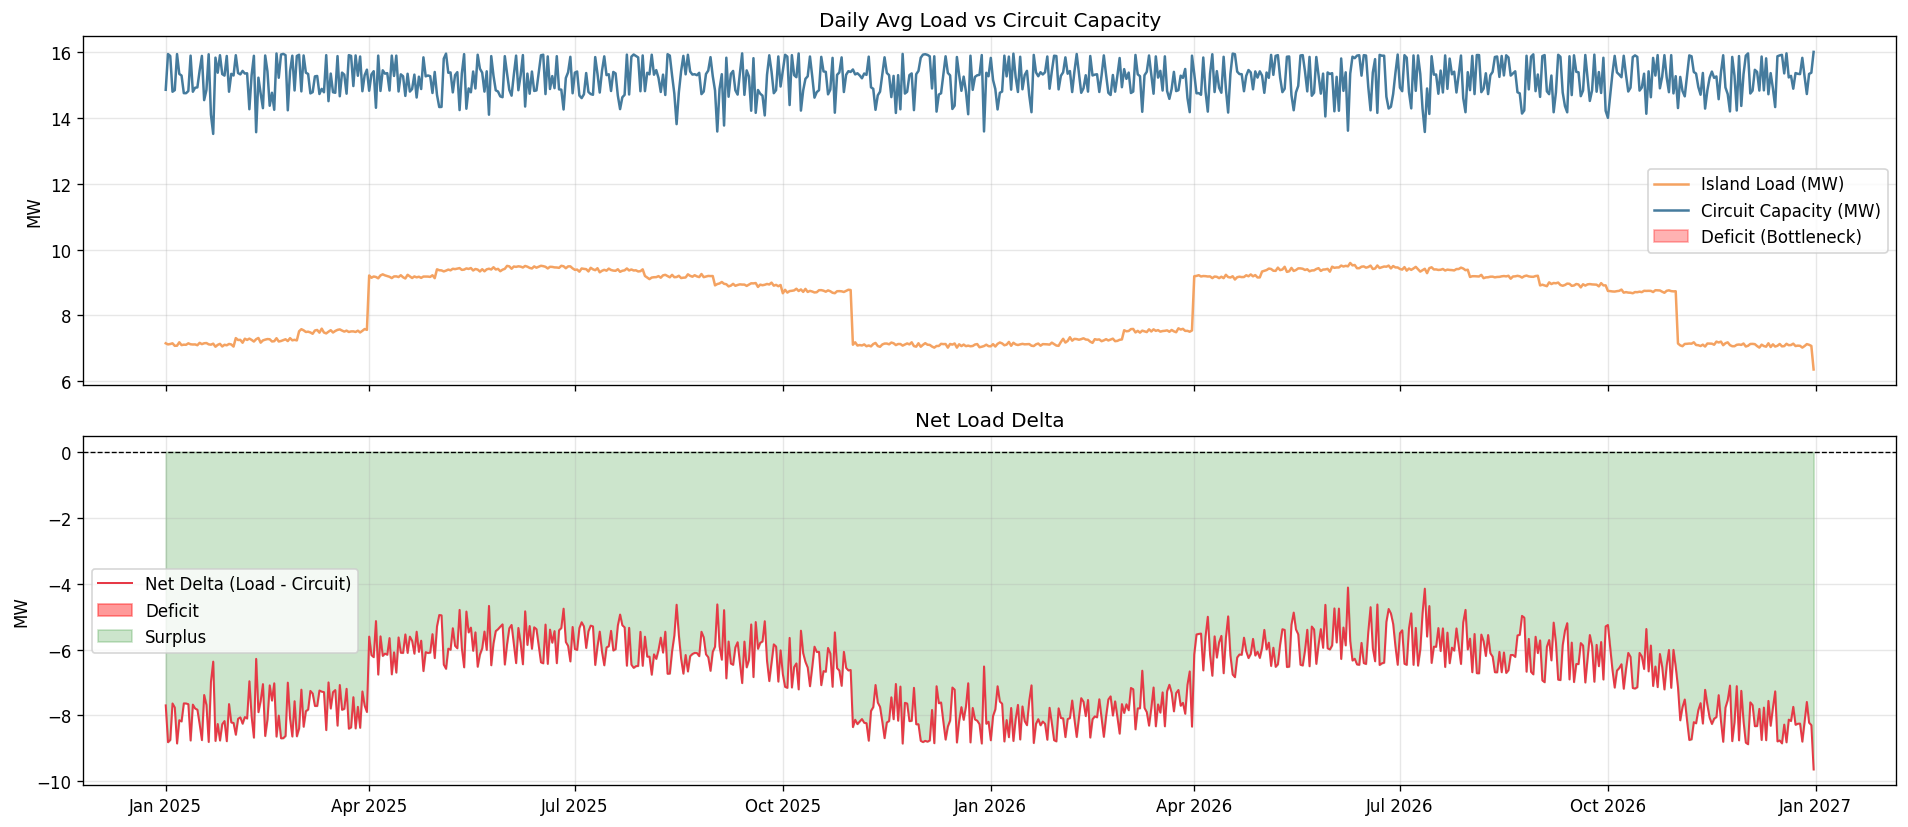

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

# Daily averages for readability
daily = raw.resample('D').mean()

axes[0].plot(daily.index, daily['Island_Load_MW'], color='#f4a261', lw=1.5, label='Island Load (MW)')
axes[0].plot(daily.index, daily['Circuit_Cap_MW'], color='#457b9d', lw=1.5, label='Circuit Capacity (MW)')
axes[0].fill_between(daily.index,
    daily['Island_Load_MW'], daily['Circuit_Cap_MW'],
    where=daily['Island_Load_MW'] > daily['Circuit_Cap_MW'],
    alpha=0.3, color='red', label='Deficit (Bottleneck)')
axes[0].set_ylabel('MW'); axes[0].legend(); axes[0].set_title('Daily Avg Load vs Circuit Capacity')
axes[0].grid(alpha=0.3)

axes[1].plot(daily.index, daily['Net_Delta_MW'], color='#e63946', lw=1.2, label='Net Delta (Load - Circuit)')
axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].fill_between(daily.index, daily['Net_Delta_MW'], 0,
    where=daily['Net_Delta_MW'] > 0, alpha=0.4, color='red', label='Deficit')
axes[1].fill_between(daily.index, daily['Net_Delta_MW'], 0,
    where=daily['Net_Delta_MW'] <= 0, alpha=0.2, color='green', label='Surplus')
axes[1].set_ylabel('MW'); axes[1].legend(); axes[1].set_title('Net Load Delta')
axes[1].grid(alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig('../results/01_load_vs_circuit.png', bbox_inches='tight')
plt.show()

## 2. Bottleneck Event Distribution

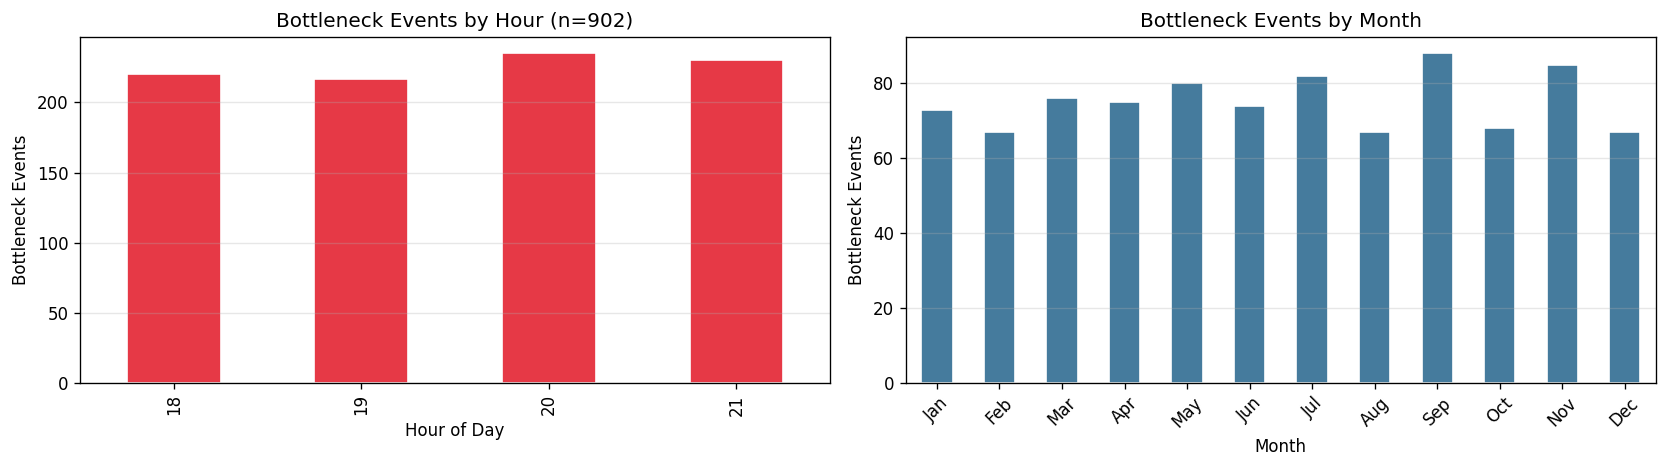

Total bottleneck hours: 902 / 17,497 (5.2%)


In [3]:
bottleneck = raw[raw['Circuit_Cap_MW'] < 5]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# By hour of day
bottleneck.groupby(bottleneck.index.hour).size().plot(
    kind='bar', ax=axes[0], color='#e63946', edgecolor='white')
axes[0].set_xlabel('Hour of Day'); axes[0].set_ylabel('Bottleneck Events')
axes[0].set_title(f'Bottleneck Events by Hour (n={len(bottleneck):,})')
axes[0].grid(axis='y', alpha=0.3)

# By month
bottleneck.groupby(bottleneck.index.month).size().plot(
    kind='bar', ax=axes[1], color='#457b9d', edgecolor='white')
axes[1].set_xlabel('Month'); axes[1].set_ylabel('Bottleneck Events')
axes[1].set_title('Bottleneck Events by Month')
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/02_bottleneck_distribution.png', bbox_inches='tight')
plt.show()
print(f'Total bottleneck hours: {len(bottleneck):,} / {len(raw):,} ({len(bottleneck)/len(raw)*100:.1f}%)')

## 3. BESS State of Charge Cycles

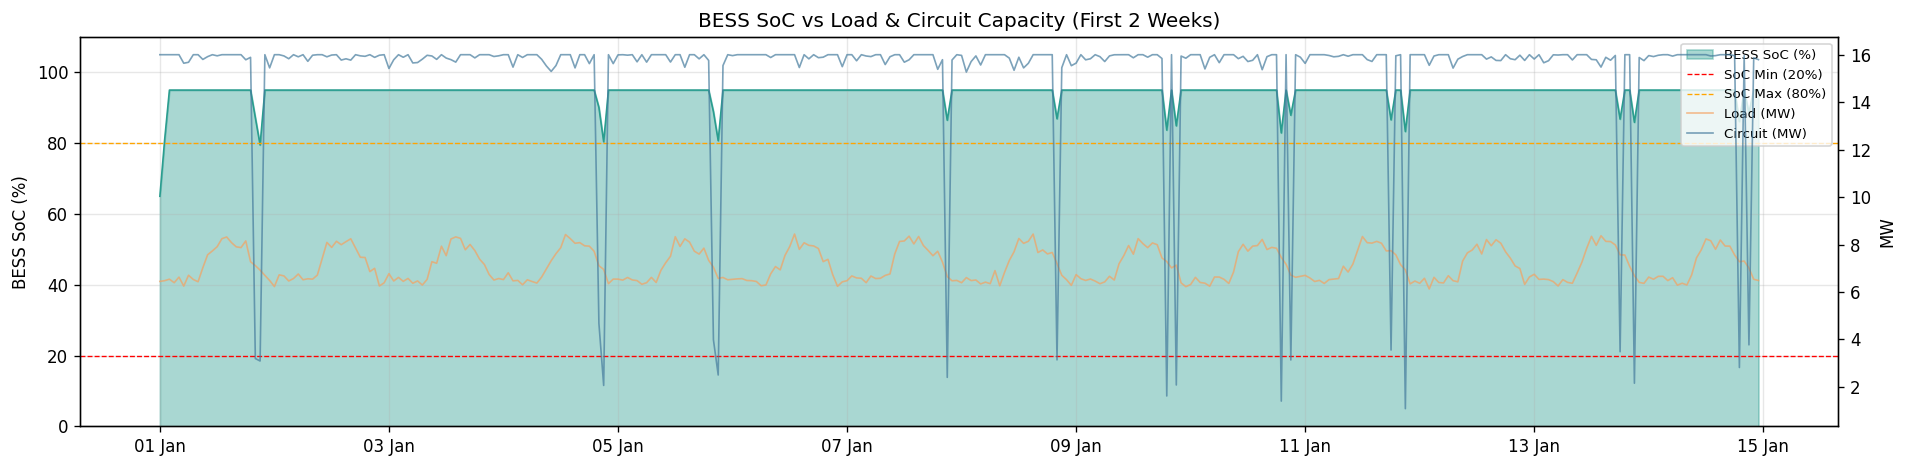

In [4]:
# Show 2 weeks of BESS SoC
sample = raw.iloc[:24*14]

fig, ax1 = plt.subplots(figsize=(16, 4))
ax2 = ax1.twinx()

ax1.fill_between(sample.index, sample['BESS_SoC_Pct'],
    alpha=0.4, color='#2a9d8f', label='BESS SoC (%)')
ax1.plot(sample.index, sample['BESS_SoC_Pct'], color='#2a9d8f', lw=1)
ax1.axhline(20, color='red', ls='--', lw=0.8, label='SoC Min (20%)')
ax1.axhline(80, color='orange', ls='--', lw=0.8, label='SoC Max (80%)')
ax1.set_ylabel('BESS SoC (%)'); ax1.set_ylim(0, 110)

ax2.plot(sample.index, sample['Island_Load_MW'], color='#f4a261', lw=1, alpha=0.7, label='Load (MW)')
ax2.plot(sample.index, sample['Circuit_Cap_MW'], color='#457b9d', lw=1, alpha=0.7, label='Circuit (MW)')
ax2.set_ylabel('MW')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)
ax1.set_title('BESS SoC vs Load & Circuit Capacity (First 2 Weeks)')
ax1.grid(alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

plt.tight_layout()
plt.savefig('../results/03_bess_soc_cycles.png', bbox_inches='tight')
plt.show()

## 4. Forecast Accuracy (Hybrid Model on Test Set)

In [5]:
ROOT = os.path.abspath('..')

def lgbm_predict_subprocess(parquet_path):
    out = tempfile.mktemp(suffix='.npy')
    script = f"""
import os, sys, pickle
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
sys.path.insert(0, {repr(ROOT)})
import numpy as np, pandas as pd
from models.lgbm_model import FEATURES
with open('models/lgbm.pkl','rb') as f: model = pickle.load(f)
df = pd.read_parquet({repr(parquet_path)})
np.save({repr(out)}, model.predict(df[FEATURES]))
"""
    subprocess.run([sys.executable, '-c', script], cwd=ROOT, check=True, capture_output=True)
    v = np.load(out); os.unlink(out); return v

from models.tcn_model import TCN, WindowDataset
from models.device import get_device
from torch.utils.data import DataLoader

device = get_device()
ckpt = torch.load('../models/tcn.pt', map_location=device)
tc = ckpt['config']
net = TCN(ckpt['in_features'], tc['filters'], tc['kernel_size'], tc['layers'], tc['forecast_horizon']).to(device)
net.load_state_dict(ckpt['state_dict']); net.eval()

ds = WindowDataset(test, tc['window_size'], tc['forecast_horizon'])
dl = DataLoader(ds, batch_size=256, num_workers=0)
tcn_preds = []
with torch.no_grad():
    for xb, _ in dl: tcn_preds.append(net(xb.to(device)).cpu().numpy())
tcn_arr = np.concatenate(tcn_preds)[:, 0]
aligned = np.full(len(test), np.nan)
aligned[tc['window_size']: tc['window_size'] + len(tcn_arr)] = tcn_arr

lgbm_arr = lgbm_predict_subprocess(os.path.join(ROOT, 'data/test.parquet'))
with open('../models/meta_learner.pkl','rb') as f: meta = pickle.load(f)

mask = ~np.isnan(aligned)
X = np.column_stack([lgbm_arr[mask], aligned[mask]])
hybrid = meta.predict(X)
y_true = test['Island_Load_MW'].values[mask]

print(f"MAPE: {np.mean(np.abs((y_true-hybrid)/y_true))*100:.4f}%")
print(f"MAE:  {np.mean(np.abs(y_true-hybrid)):.4f} MW")

MAPE: 1.6554%
MAE:  0.1263 MW


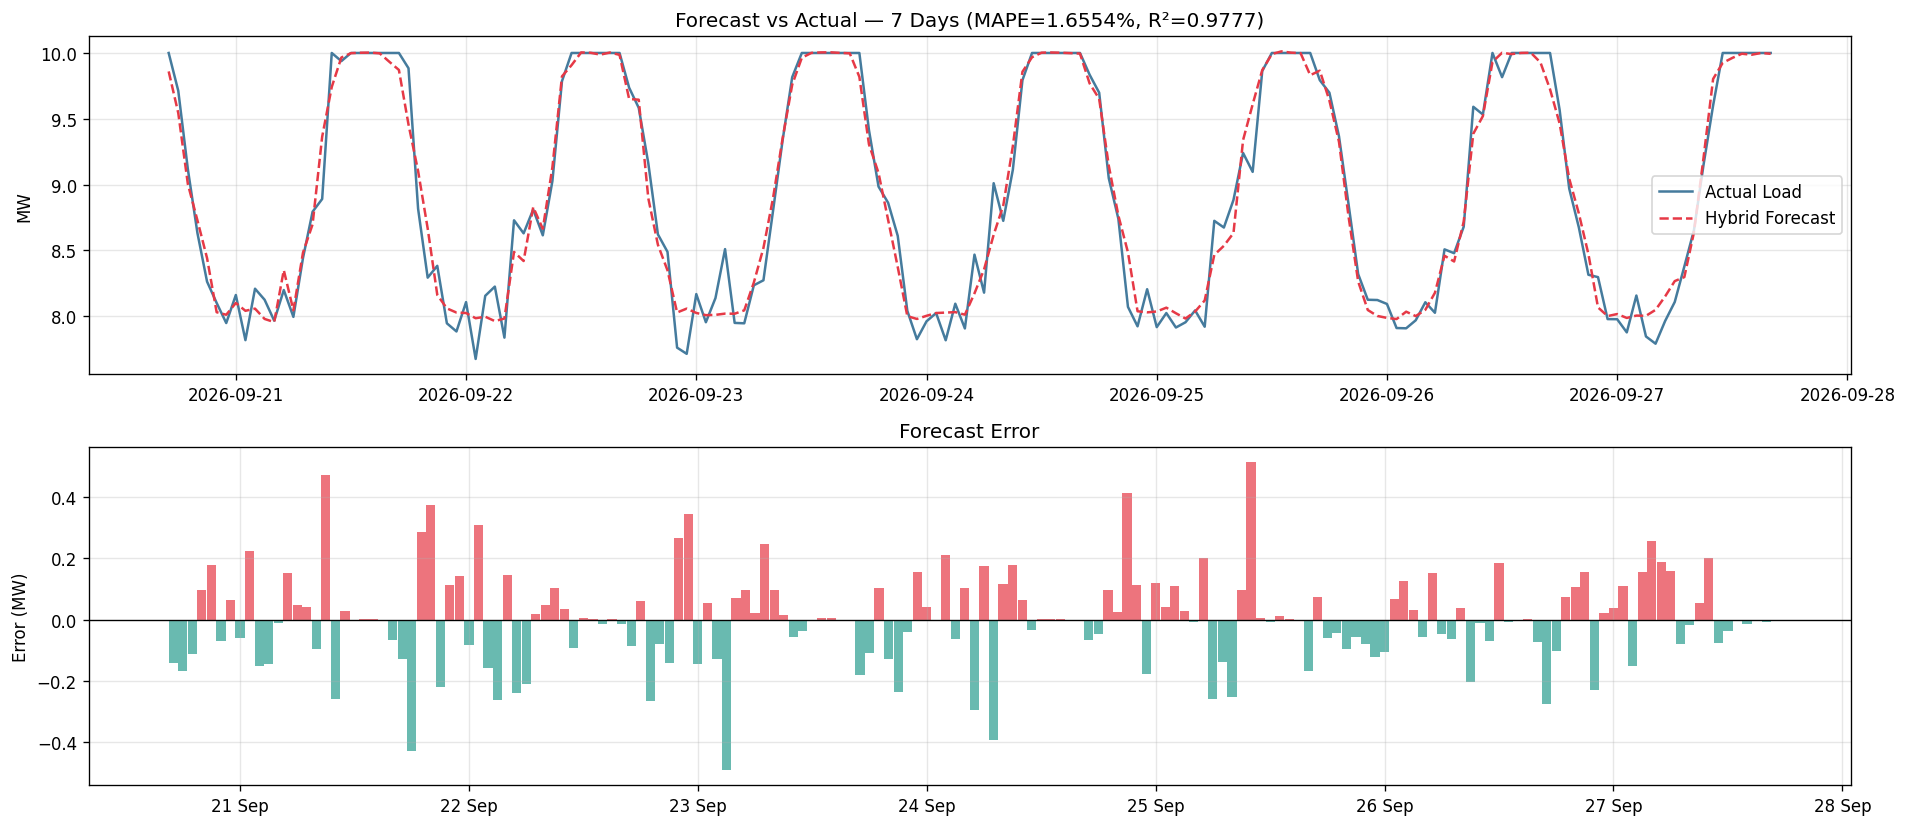

In [6]:
# Plot 7-day forecast vs actual
n = 24 * 7
idx = test.index[mask][:n]

fig, axes = plt.subplots(2, 1, figsize=(16, 7))

axes[0].plot(idx, y_true[:n], color='#457b9d', lw=1.5, label='Actual Load')
axes[0].plot(idx, hybrid[:n], color='#e63946', lw=1.5, ls='--', label='Hybrid Forecast')
axes[0].set_ylabel('MW'); axes[0].legend()
axes[0].set_title(f'Forecast vs Actual — 7 Days (MAPE={report["forecast"]["mape"]}%, R²={report["forecast"]["r2"]})')
axes[0].grid(alpha=0.3)

errors = hybrid[:n] - y_true[:n]
axes[1].bar(idx, errors, color=np.where(errors > 0, '#e63946', '#2a9d8f'), width=0.04, alpha=0.7)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_ylabel('Error (MW)'); axes[1].set_title('Forecast Error')
axes[1].grid(alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

plt.tight_layout()
plt.savefig('../results/04_forecast_accuracy.png', bbox_inches='tight')
plt.show()

## 5. Dispatch Schedule — Sample Day

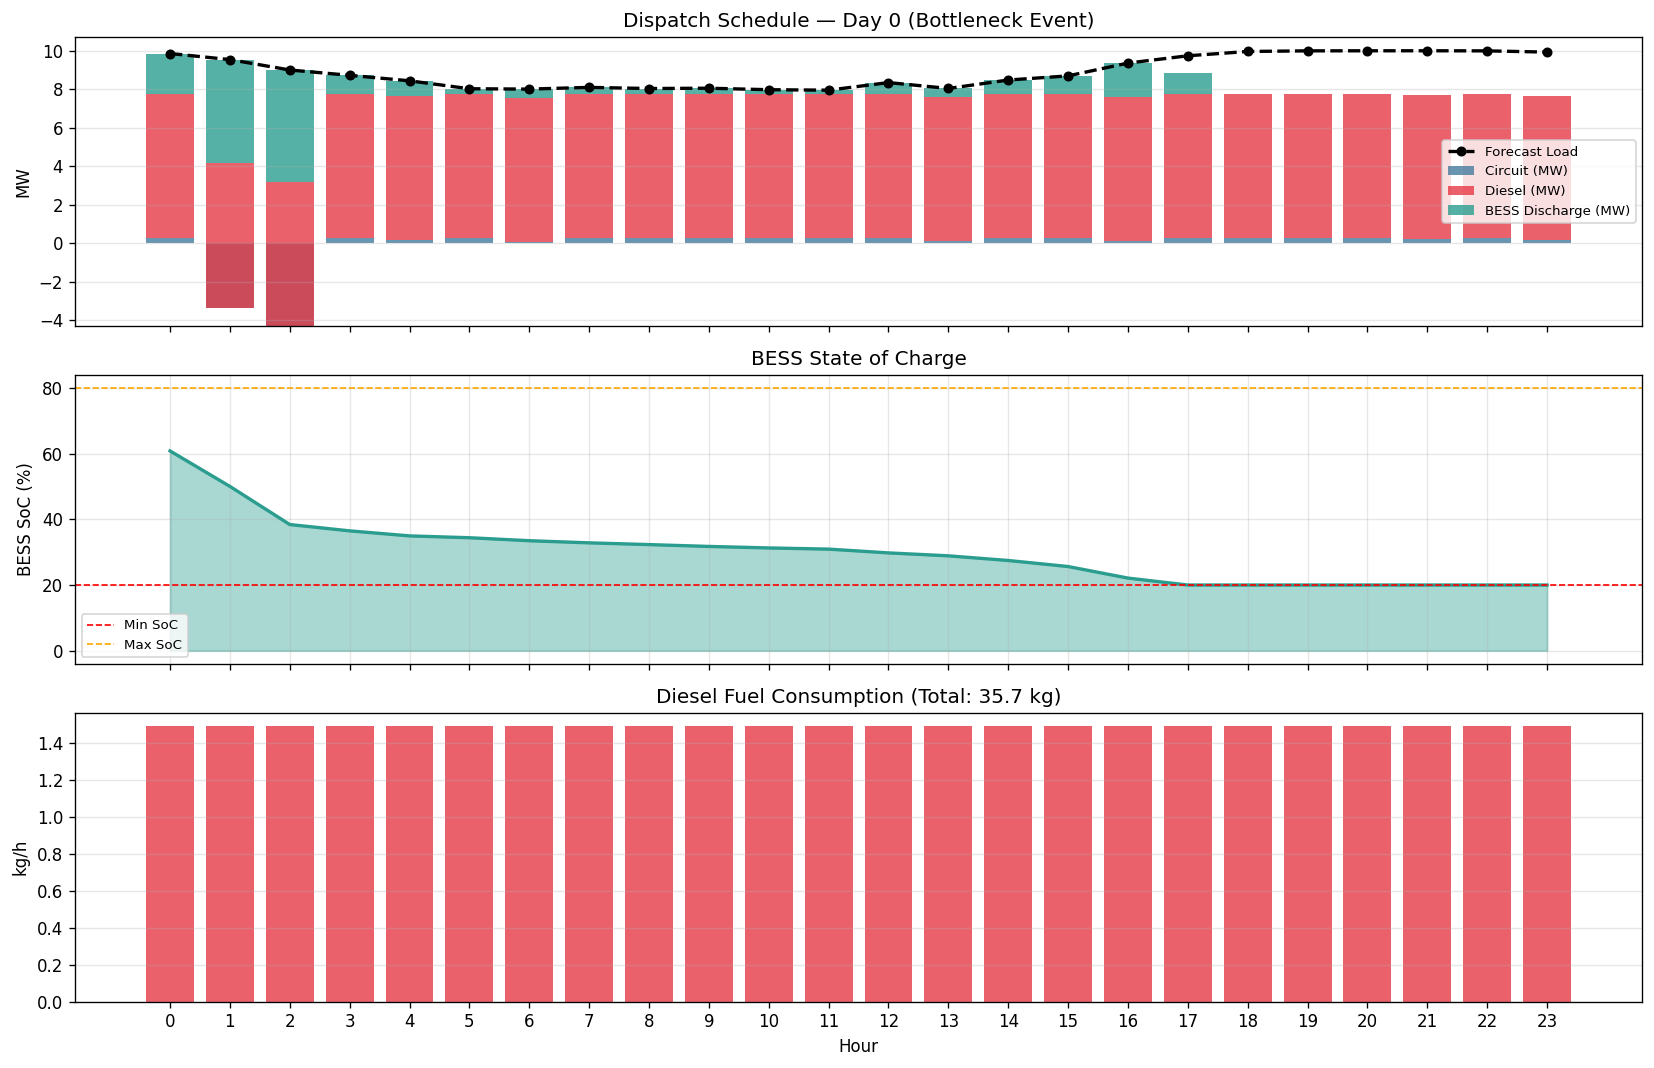

In [7]:
from optimizer.dispatch import run_dispatch

# Pick a bottleneck day from test set
circuit_test = test['Circuit_Cap_MW'].values[mask]
bottleneck_days = np.where(circuit_test[:len(hybrid)//24*24].reshape(-1,24).min(axis=1) < 5)[0]
day_idx = bottleneck_days[0] if len(bottleneck_days) else 0

load_day    = hybrid[day_idx*24:(day_idx+1)*24]
circuit_day = circuit_test[day_idx*24:(day_idx+1)*24]
sched = run_dispatch(load_day, circuit_day, cfg=cfg)

hours      = [s.hour for s in sched]
diesel_mw  = [s.diesel_mw for s in sched]
bess_mw    = [s.bess_mw for s in sched]
bess_soc   = [s.bess_soc * 100 for s in sched]
fuel_kg    = [s.fuel_kg for s in sched]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# Power balance
axes[0].bar(hours, circuit_day, label='Circuit (MW)', color='#457b9d', alpha=0.8)
axes[0].bar(hours, diesel_mw, bottom=circuit_day, label='Diesel (MW)', color='#e63946', alpha=0.8)
axes[0].bar(hours, np.maximum(bess_mw, 0), bottom=circuit_day + np.array(diesel_mw),
            label='BESS Discharge (MW)', color='#2a9d8f', alpha=0.8)
axes[0].plot(hours, load_day, 'ko--', lw=2, ms=5, label='Forecast Load')
axes[0].set_ylabel('MW'); axes[0].legend(fontsize=8)
axes[0].set_title(f'Dispatch Schedule — Day {day_idx} (Bottleneck Event)')
axes[0].grid(axis='y', alpha=0.3)

# BESS SoC
axes[1].fill_between(hours, bess_soc, alpha=0.4, color='#2a9d8f')
axes[1].plot(hours, bess_soc, color='#2a9d8f', lw=2)
axes[1].axhline(20, color='red', ls='--', lw=1, label='Min SoC')
axes[1].axhline(80, color='orange', ls='--', lw=1, label='Max SoC')
axes[1].set_ylabel('BESS SoC (%)'); axes[1].legend(fontsize=8)
axes[1].set_title('BESS State of Charge')
axes[1].grid(alpha=0.3)

# Fuel consumption
axes[2].bar(hours, fuel_kg, color='#e63946', alpha=0.8, label='Fuel (kg/h)')
axes[2].set_ylabel('kg/h'); axes[2].set_xlabel('Hour')
axes[2].set_title(f'Diesel Fuel Consumption (Total: {sum(fuel_kg):.1f} kg)')
axes[2].set_xticks(hours)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/05_dispatch_schedule.png', bbox_inches='tight')
plt.show()

## 6. Summary Dashboard

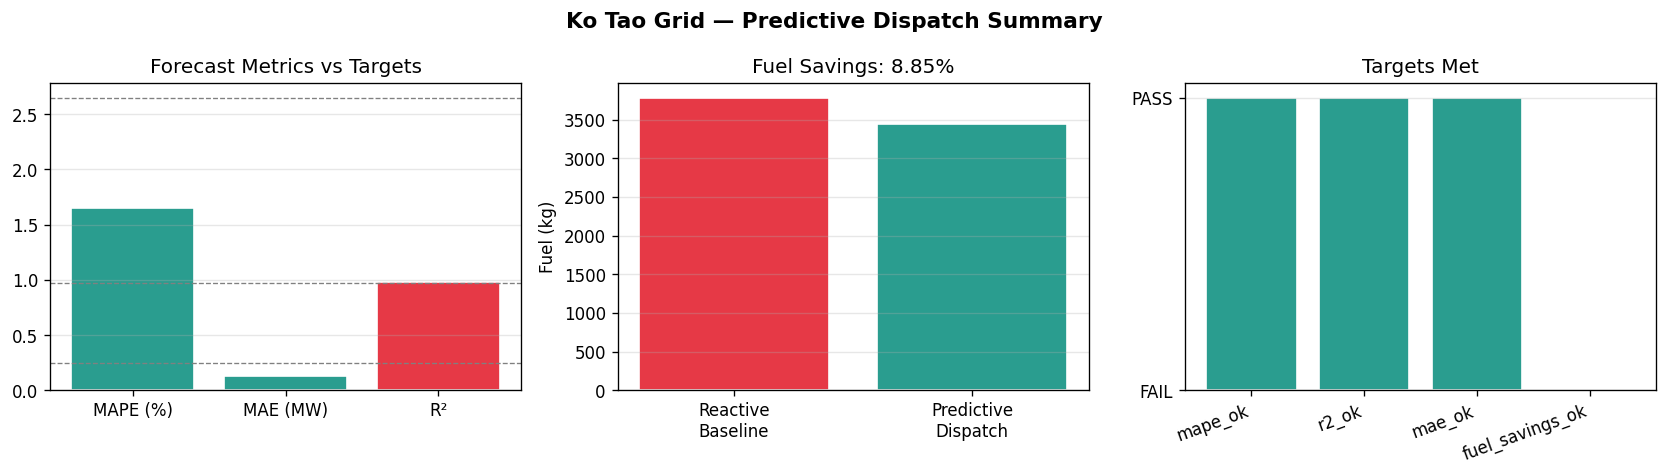


All charts saved to results/


In [8]:
d = report['dispatch']
f = report['forecast']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Forecast metrics
metrics = ['MAPE (%)', 'MAE (MW)', 'R²']
values  = [f['mape'], f['mae'], f['r2']]
targets = [2.65, 0.25, 0.97]
colors  = ['#2a9d8f' if v <= t else '#e63946' for v, t in zip(values, targets)]
bars = axes[0].bar(metrics, values, color=colors, edgecolor='white')
for bar, tgt in zip(bars, targets):
    axes[0].axhline(tgt, color='gray', ls='--', lw=0.8)
axes[0].set_title('Forecast Metrics vs Targets'); axes[0].grid(axis='y', alpha=0.3)

# Fuel savings
axes[1].bar(['Reactive\nBaseline', 'Predictive\nDispatch'],
            [d['reactive_fuel_kg'], d['total_fuel_kg']],
            color=['#e63946', '#2a9d8f'], edgecolor='white')
axes[1].set_ylabel('Fuel (kg)'); axes[1].set_title(f'Fuel Savings: {d["fuel_savings_pct"]}%')
axes[1].grid(axis='y', alpha=0.3)

# Targets met
tm = report['targets_met']
labels = list(tm.keys())
vals   = [1 if v else 0 for v in tm.values()]
colors2 = ['#2a9d8f' if v else '#e63946' for v in vals]
axes[2].bar(labels, vals, color=colors2, edgecolor='white')
axes[2].set_yticks([0, 1]); axes[2].set_yticklabels(['FAIL', 'PASS'])
axes[2].set_title('Targets Met'); axes[2].grid(axis='y', alpha=0.3)
plt.setp(axes[2].get_xticklabels(), rotation=20, ha='right')

plt.suptitle('Ko Tao Grid — Predictive Dispatch Summary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/06_summary_dashboard.png', bbox_inches='tight')
plt.show()

print('\nAll charts saved to results/')